# Hugging Face Starter
Bootstrap your projects with Hugging Face Pretrained Models. This notebook tests out some of the available models.

1. [Named Entity Recognition (NER)](#1.-Named-Entity-Recognition-(NER))
2. [Text Generator](#2.-Text-Generator)
3. [Text Summarizer](#3.-Text-Summarizer)
4. [Question Answering](#4.-Question-Answering)
5. [Classifier: Sentiment Analysis](#5.-Classifier:-Sentiment-Analysis)
6. [Classifier: Image Classification](#6.-Classifier:-Image-Segmentation)
7. [Object Detection](#7.-Object-Detection)
8. [Image Segmentation](#8.-Image-Segmentation)
9. [Zero-Shot Classification](#9.-Zero-Shot-classififcation)
10. [Translation](#10.-Translation)

In [1]:
!pip install torch transformers tf-keras
!pip install timm

import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import requests
from io import BytesIO
from transformers import pipeline
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

/opt/anaconda3/envs/tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
from dotenv import load_dotenv

load_dotenv()  # reads API key from .env file

True

## 1. Named Entity Recognition (NER)

In [15]:
ner_pipeline = pipeline('ner')
text = "Hugging Face is a company located in New York City and Paris."
entities = ner_pipeline(text)

entities

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision f2482bf (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[{'entity': 'I-ORG',
  'score': np.float32(0.9936765),
  'index': 1,
  'word': 'Hu',
  'start': 0,
  'end': 2},
 {'entity': 'I-ORG',
  'score': np.float32(0.8772726),
  'index': 2,
  'word': '##gging',
  'start': 2,
  'end': 7},
 {'entity': 'I-ORG',
  'score': np.float32(0.9617203),
  'index': 3,
  'word': 'Face',
  'start': 8,
  'end': 12},
 {'entity': 'I-LOC',
  'score': np.float32(0.9990528),
  'index': 9,
  'word': 'New',
  'start': 37,
  'end': 40},
 {'entity': 'I-LOC',
  'score': np.float32(0.9987709),
  'index': 10,
  'word': 'York',
  'start': 41,
  'end': 45},
 {'entity': 'I-LOC',
  'score': np.float32(0.999233),
  'index': 11,
  'word': 'City',
  'start': 46,
  'end': 50},
 {'entity': 'I-LOC',
  'score': np.float32(0.99869424),
  'index': 13,
  'word': 'Paris',
  'start': 55,
  'end': 60}]

## 2. Text Generator

In [16]:
text_generator = pipeline('text-generation', model='openai-community/gpt2')
prompt = "Cats are wonderful pets because"
generated_text = text_generator(prompt, max_length=100, num_return_sequences=1)

print(generated_text[0]['generated_text'])

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Cats are wonderful pets because they just need to be home to themselves. So many stray cats and kittens are being sent away by their rescuers and don't deserve that sort of "back up" on the streets, as I had hoped for from my new home. I think this is a really big step in making that happen."

With the city building the new $16-million new arena and the new new arena from a commercial development (Dundas, which also includes a condo


## 3. Text Summarizer

In [17]:
text_generator = pipeline('text-generation')
## remove the previous prompt from generated text
article = generated_text[0]['generated_text']
prompt = "Summarize the article: " + article

summary = text_generator(prompt, max_new_tokens=50, num_return_sequences=1)
print(summary[0]['generated_text'])

No model was supplied, defaulted to openai-community/gpt2 and revision 6c0e608 (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Summarize the article: Cats are wonderful pets because they just need to be home to themselves. So many stray cats and kittens are being sent away by their rescuers and don't deserve that sort of "back up" on the streets, as I had hoped for from my new home. I think this is a really big step in making that happen."

With the city building the new $16-million new arena and the new new arena from a commercial development (Dundas, which also includes a condo complex), the city is paying $150 million for $65-million in new mixed-use parking.


"We were very confident we'd build a solid commercial structure, but we want you to think about what you have to build out of


## 4. Question Answering

In [18]:
question_answerer = pipeline('question-answering')

context = "Hugging Face is an artificial intelligence company."
question = "Who is the PM of India"

answer = question_answerer(question=question, context=context)

answer

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 626af31 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


{'score': 0.6458468437194824, 'start': 0, 'end': 12, 'answer': 'Hugging Face'}

## 5. Classifier: Sentiment Analysis 

In [19]:
from tqdm.auto import tqdm


models = ['ProsusAI/finbert', 'cardiffnlp/twitter-roberta-base-sentiment-latest','microsoft/deberta-xlarge-mnli']
tweets = ['Amazing movie, must watch!', 'It was okay, one-time watch', 'Do not recommend it.']
logs = []


for model in tqdm(models):
  sentiment_analyzer = pipeline('sentiment-analysis', model = model)

  for tweet in tweets:
      result = sentiment_analyzer(tweet)
      logs.append([model, tweet, result[0]['label'], result[0]['score']])

 33%|███▎      | 1/3 [00:01<00:02,  1.40s/it]Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 3/3 [00:15<00:00,  5.31s/it]


## 6. Classifier: Image Segmentation

No model was supplied, defaulted to google/vit-base-patch16-224 and revision 5dca96d (https://huggingface.co/google/vit-base-patch16-224).
Using a pipeline without specifying a model name and revision in production is not recommended.


[{'label': 'Egyptian cat', 'score': 0.9374414682388306}, {'label': 'tabby, tabby cat', 'score': 0.03844261169433594}, {'label': 'tiger cat', 'score': 0.01441141590476036}, {'label': 'lynx, catamount', 'score': 0.003274334827437997}, {'label': 'Siamese cat, Siamese', 'score': 0.0006795944063924253}]


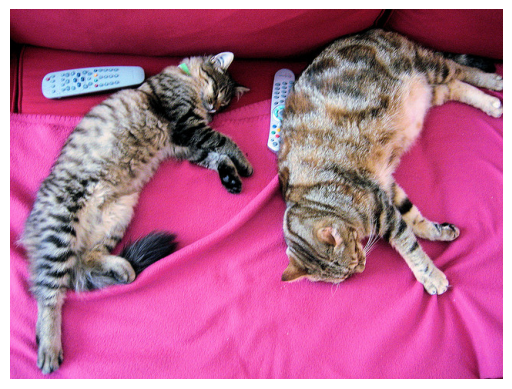

In [20]:
image_classifier = pipeline("image-classification")

image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

classification_results = image_classifier(image)

print(classification_results)

plt.imshow(image)
plt.axis("off")
plt.show()

## 7. Object Detection

No model was supplied, defaulted to facebook/detr-resnet-50 and revision 2729413 (https://huggingface.co/facebook/detr-resnet-50).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a 

[{'score': 0.9982203841209412, 'label': 'remote', 'box': {'xmin': 40, 'ymin': 70, 'xmax': 175, 'ymax': 117}}, {'score': 0.9960022568702698, 'label': 'remote', 'box': {'xmin': 333, 'ymin': 72, 'xmax': 368, 'ymax': 187}}, {'score': 0.9954743981361389, 'label': 'couch', 'box': {'xmin': 0, 'ymin': 1, 'xmax': 639, 'ymax': 473}}, {'score': 0.99880051612854, 'label': 'cat', 'box': {'xmin': 13, 'ymin': 52, 'xmax': 314, 'ymax': 470}}, {'score': 0.9986782670021057, 'label': 'cat', 'box': {'xmin': 345, 'ymin': 23, 'xmax': 640, 'ymax': 368}}]


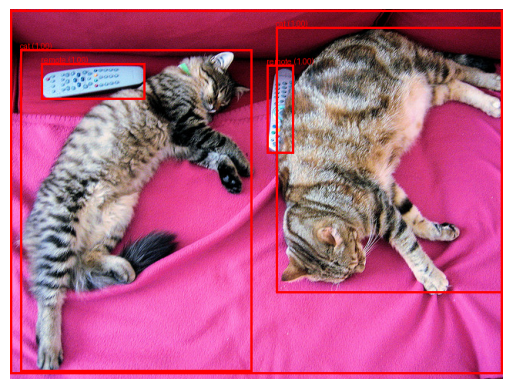

In [21]:
object_detector = pipeline("object-detection")

image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

detection_results = object_detector(image)
print(detection_results)

draw = ImageDraw.Draw(image)
for obj in detection_results:
    box = obj["box"]
    label = obj["label"]
    score = obj["score"]

    # Draw rectangle
    draw.rectangle(
        [(box["xmin"], box["ymin"]), (box["xmax"], box["ymax"])],
        outline="red", width=3
    )
    # Add label + score
    draw.text((box["xmin"], box["ymin"] - 10), f"{label} ({score:.2f})", fill="red")


plt.imshow(image)
plt.axis("off")
plt.show()

## 8. Image Segmentation

No model was supplied, defaulted to facebook/detr-resnet-50-panoptic and revision fc15262 (https://huggingface.co/facebook/detr-resnet-50-panoptic).
Using a pipeline without specifying a model name and revision in production is not recommended.


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/detr-resnet-50-panoptic were not used when initializing DetrForSegmentation: ['detr.model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForSegmentation from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- Th

[{'score': 0.994097, 'label': 'cat', 'mask': <PIL.Image.Image image mode=L size=640x480 at 0x33264A1D0>}, {'score': 0.998669, 'label': 'remote', 'mask': <PIL.Image.Image image mode=L size=640x480 at 0x33264A290>}, {'score': 0.999476, 'label': 'remote', 'mask': <PIL.Image.Image image mode=L size=640x480 at 0x332649BD0>}, {'score': 0.972207, 'label': 'couch', 'mask': <PIL.Image.Image image mode=L size=640x480 at 0x33264A230>}, {'score': 0.999424, 'label': 'cat', 'mask': <PIL.Image.Image image mode=L size=640x480 at 0x332649D20>}]


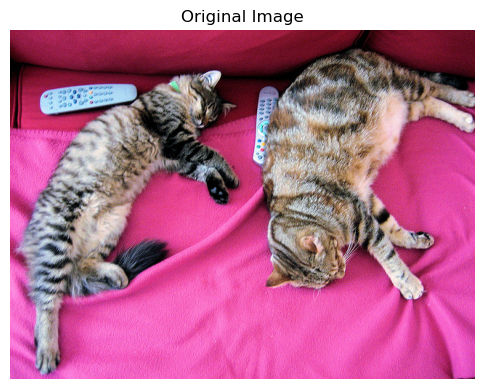

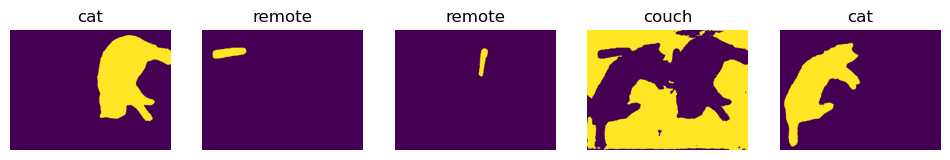

In [2]:
image_segmentor = pipeline("image-segmentation")

image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

segmentation_results = image_segmentor(image)
print(segmentation_results)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

plt.figure(figsize=(12, 12))
for i, result in enumerate(segmentation_results):
    mask = result["mask"]  # segmentation mask
    label = result["label"]
    plt.subplot(1, len(segmentation_results), i+1)
    plt.imshow(mask)
    plt.axis("off")
    plt.title(label)

plt.show()

## 9. Zero-Shot classififcation

In [3]:
zero_shot_classifier = pipeline('zero-shot-classification')

sequence_to_classify = "Hello, how are you today? Are you available for a meeting tomorrow at 10am at the Central Park, New York?"

candidate_labels = ["Time","Location","Event", "Python", "Finance"]

classification_results = zero_shot_classifier(sequence_to_classify, candidate_labels)

for label, score in zip(classification_results['labels'], classification_results['scores']):
    print(label, score)

No model was supplied, defaulted to facebook/bart-large-mnli and revision c626438 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


Location 0.5414189696311951
Event 0.3340553641319275
Time 0.06534762680530548
Python 0.03978214040398598
Finance 0.01939588598906994


## 10. Translation

In [1]:
from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-en-hi"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

english_text = "Hello, good morning, how are you?"
tokens = tokenizer(english_text, return_tensors="pt", padding=True)
translated = model.generate(**tokens)

print(tokenizer.decode(translated[0], skip_special_tokens=True))

/opt/anaconda3/envs/tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/tf/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/opt/anaconda3/envs/tf/lib/python3.10/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


हैलो, सुप्रभात, तुम कैसे हो?
